In [1]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ExpSineSquared, DotProduct
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
from skopt import gp_minimize
from skopt.space import Real
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.optimize import minimize

In [2]:
inputs1 = np.array([[0.31940389, 0.76295937],
       [0.57432921, 0.8798981 ],
       [0.73102363, 0.73299988],
       [0.84035342, 0.26473161],
       [0.65011406, 0.68152635],
       [0.41043714, 0.1475543 ],
       [0.31269116, 0.07872278],
       [0.68341817, 0.86105746],
       [0.08250725, 0.40348751],
       [0.88388983, 0.58225397],
       [0.313131, 0.080808],
       [0.819461, 0.714329],
       [0.811000, 0.157249]])

In [3]:
outputs1 = np.array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
        3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
       -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
        6.22985647e-048, -2.9364314294151675e-90, -1.4894966647291057e-31, 4.6334745434986095e-155])

# Q1 Code Review

## Surrogate model

In [4]:
# 10 samples, 2D input, 1D output
# ------------------------------
X = inputs1
y = outputs1

# ------------------------------
# Define the GP kernel: Constant * RBF
# RBF length scale can be optimized during fitting
# kernel is used to simulate the shape of the function
# (https://andrewcharlesjones.github.io/journal/matern-kernels.html)
kernel_best_Q1_RBF = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2)) 

# Initialize Gaussian Process Regressor
gp = GaussianProcessRegressor(kernel=kernel_best_Q1_RBF, n_restarts_optimizer=20, alpha=1e-6, normalize_y=True)
# the default optimizer would be used if no value is passed to the optimizer arguments
# n_restarts_optimizer >> kind of control how many times the optimizer would re-run to find the best parameter for the kernels

# Fit to data
# Train the model, GP finding the candiate functions with highest probability given the observed samples (X, y)
gp.fit(X, y)

print("Optimized kernel:", gp.kernel_)
# as the optimizer would be run to find the best parameter of the kernel, print the best kernel for reference

#mean and standard deviation of the probability distribution of P(function given observation)

Optimized kernel: 1.01**2 * RBF(length_scale=0.0484)


## Scatter plot - observations (2D)

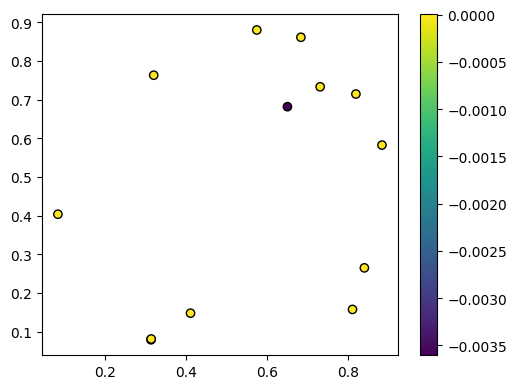

In [5]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="viridis")

plt.colorbar()

plt.tight_layout()
plt.show()

## Scatter plot - observations (3D)

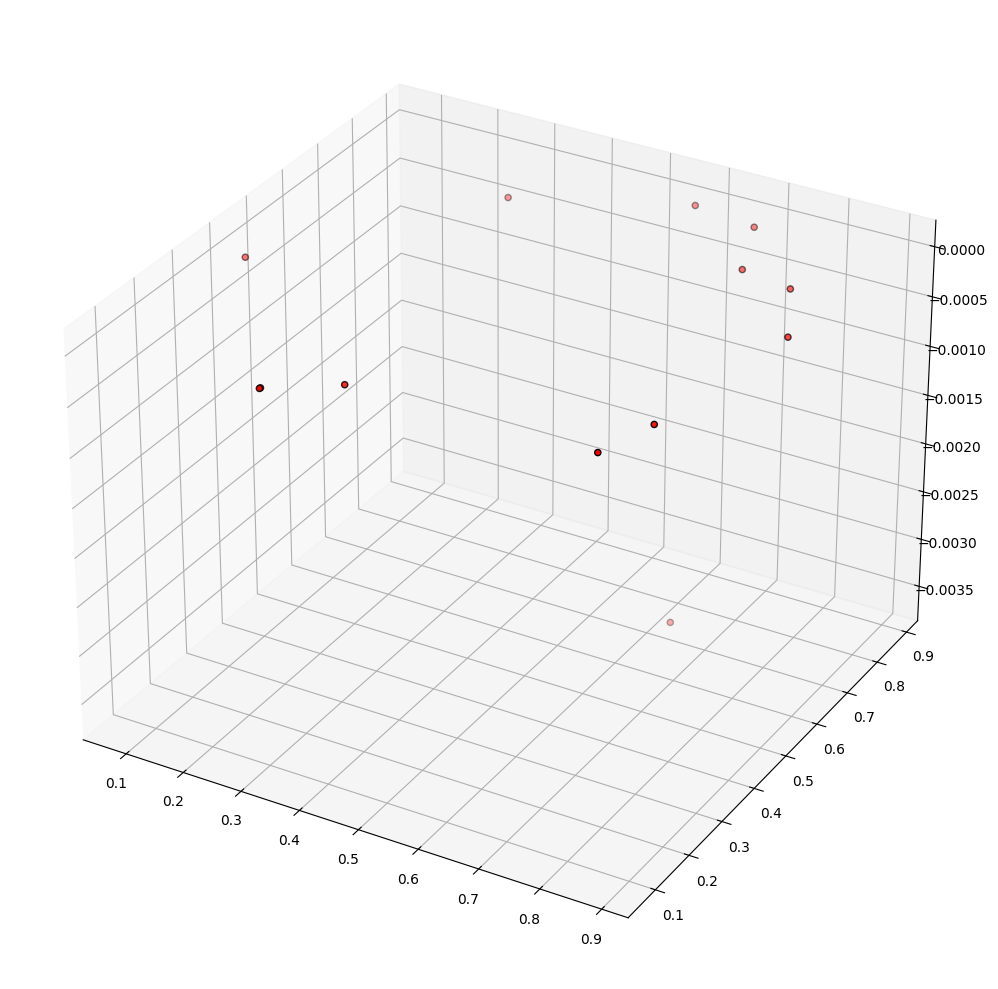

In [40]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], y, c = 'red', edgecolors="k")

plt.tight_layout()
plt.show()

## Acquisition function - Grid Search

In [34]:
def ucb(X_candidates, gp, kappa=2.0):
    mu, sigma = gp.predict(X_candidates, return_std=True)
    return mu + kappa * sigma
# ------------------------------
# Generate candidate points (dense grid in [0,1]^2)
# ------------------------------
# feed the GP with these sample input points to generate the probability distribution of f(x1, x2), i.e. target function
x1 = np.linspace(0, 1, 1000)
x2 = np.linspace(0, 1, 1000)
X1, X2 = np.meshgrid(x1, x2)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

# Compute UCB
# if kappa is large, the UCB favours exploration
# if kappa is small, the UCB favours exploitation
# kappa close to 1, balance between good values and unexplored values
ucb_values = ucb(X_grid, gp, kappa=1)

# Pick next query point (max UCB)
next_point = X_grid[np.argmax(ucb_values)]
#np.argmax >>> returns the index of maximum element in array
print("Next query point (by UCB):", next_point)

Next query point (by UCB): [0.76276276 0.77877878]


## Acquisition function - Bayesian Optimization

In [9]:
def optimize_acquisition_global(acquisition_func, gp, bounds, kappa=4.0, maxiter=100, popsize=30):
    """
    Optimize acquisition function globally using differential evolution.

    Parameters
    ----------
    acquisition_func : callable
        Acquisition function (e.g. ucb)
    gp : fitted GaussianProcessRegressor
        Trained GP model
    bounds : list of tuples
        Search space bounds [(x1_min, x1_max), (x2_min, x2_max), ...]
    kappa : float
        Exploration-exploitation parameter for UCB
    maxiter : int
        Max number of iterations for the DE optimizer
    popsize : int
        Population size multiplier for DE (higher = better exploration)

    Returns
    -------
    x_next : np.ndarray
        Next query point (best according to acquisition)
    best_val : float
        Value of acquisition function at x_next
    """
    # Objective to minimize (negative because DE minimizes)
    def objective(x):
        x = np.array(x).reshape(1, -1)
        return -acquisition_func(x, gp, kappa=kappa)[0]

    # Differential Evolution global optimization
    result = differential_evolution(
        objective,
        bounds=bounds,
        maxiter=maxiter,
        popsize=popsize,
        polish=True,       # refine the result locally at the end
        disp=True           # print optimization progress
    )

    x_next = result.x
    best_val = -result.fun
    return x_next, best_val

In [11]:
bounds = [(0, 1), (0, 1)]

next_point1, best_val1 = optimize_acquisition_global(
        acquisition_func=ucb,
        gp=gp,
        bounds=bounds,
        kappa=4.0,      # larger kappa → more exploration
        maxiter=1000,     # number of DE iterations
        popsize=30      # population size
    )

# Optimize acquisition
print("Next query point (by UCB):", next_point1)

differential_evolution step 1: f(x)= -0.0036300046457153814
differential_evolution step 2: f(x)= -0.0036300046457153814
differential_evolution step 3: f(x)= -0.003635557189826722
Polishing solution with 'L-BFGS-B'
Next query point (by UCB): [0.9188213  0.18590947]


## Predicted mean and standard deviation

In [ ]:
y_mean, y_std = gp.predict(X_grid_gs, return_std=True)

## Contour plot - Predicted mean

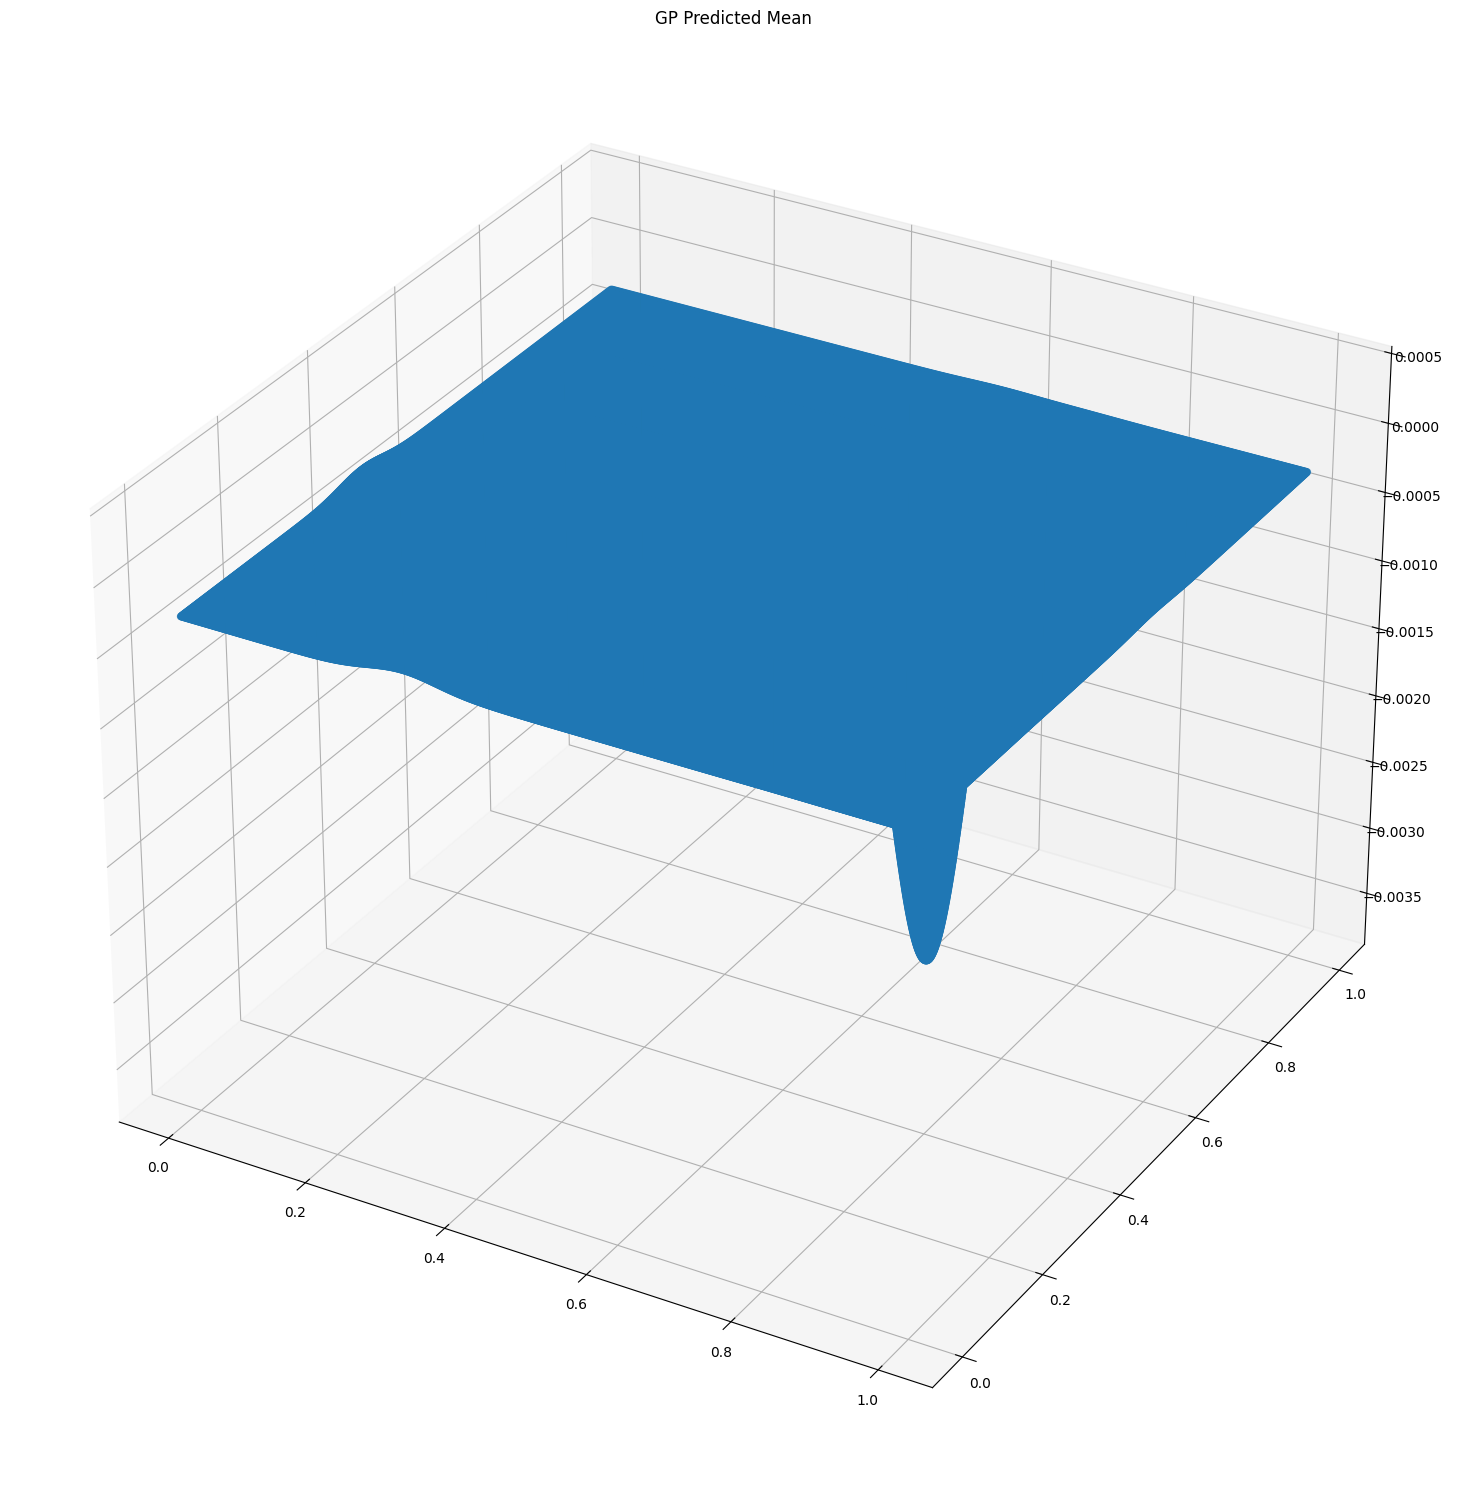

In [37]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1, X2, y_mean.reshape(X1.shape))

#ax.scatter(next_point[0], next_point[1], c="red", s=100, marker="*", label="Next query")
#ax.scatter(next_point1[0], next_point1[1], c="blue", s=100, marker="*", label="Next query1")

plt.title("GP Predicted Mean")

plt.tight_layout()
plt.show()

## Contour plot - predicted standard variation

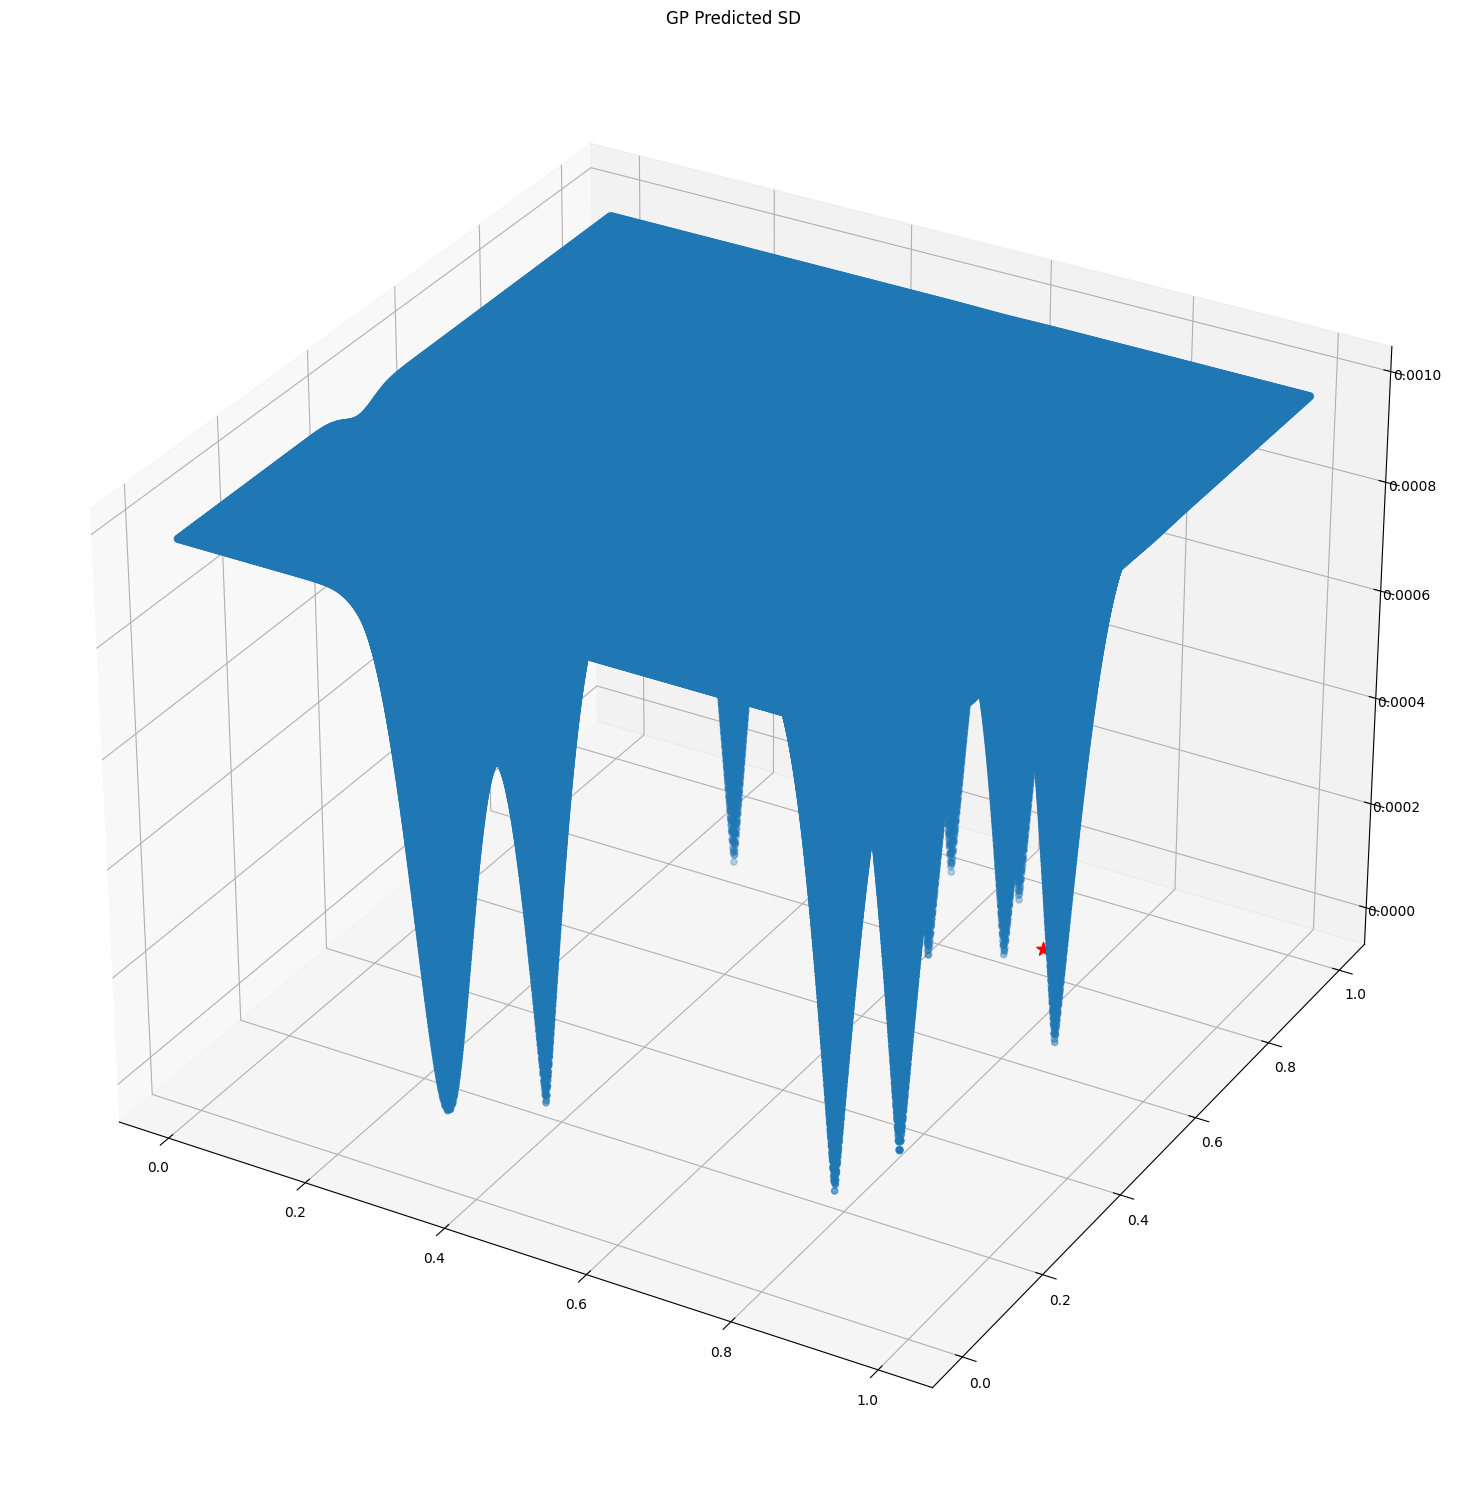

In [38]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1, X2, y_std.reshape(X1.shape))

ax.scatter(next_point[0], next_point[1], c="red", s=100, marker="*", label="Next query")

plt.title("GP Predicted SD")

plt.tight_layout()
plt.show()

## Scatter plot - Observations + next query

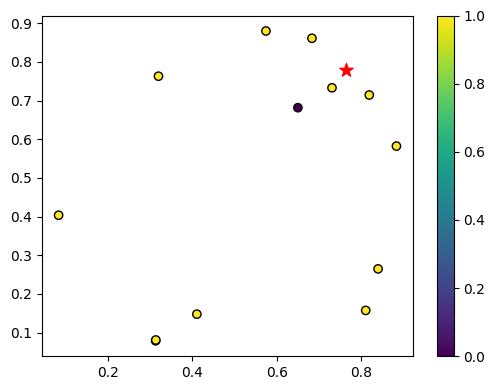

In [28]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="viridis")
plt.scatter(next_point[0], next_point[1], c="red", s=100, marker="*", label="Next query")

plt.colorbar()

plt.tight_layout()
plt.show()